In [16]:
# ════════════════════════════════════════════════════════
# SECTION 2 — SETUP & IMPORTS
# ════════════════════════════════════════════════════════
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from scipy.stats import (
    chi2_contingency, kruskal, mannwhitneyu,
    f_oneway, pearsonr, spearmanr
)

warnings.filterwarnings('ignore')

# ── Consistent visual style ───────────────────────────────────────────────────
sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams.update({
    'figure.dpi': 100,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
})

print("✅ All libraries loaded successfully.")

✅ All libraries loaded successfully.


In [17]:
# ════════════════════════════════════════════════════════
# SECTION 3 — DATA LOADING
# ════════════════════════════════════════════════════════
# Auto-detects the dataset in common environments
# (local folder, Kaggle, Google Colab).

CANDIDATE_PATHS = [
    "DataCoSupplyChainDataset.csv",                                       # Same folder as notebook
    "data/DataCoSupplyChainDataset.csv",                                  # 'data' subfolder
    "/kaggle/input/supply-chain-dataset/DataCoSupplyChainDataset.csv",    # Kaggle kernel
    "/content/DataCoSupplyChainDataset.csv",                              # Google Colab
]

DATA_PATH = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "\n❌ Dataset not found. Place 'DataCoSupplyChainDataset.csv' in the same folder as "
        "this notebook.\nDownload: https://www.kaggle.com/datasets/shashwatwork/"
        "dataco-smart-supply-chain-for-big-data-analysis"
    )

print(f"📂 Loading from: {DATA_PATH}")

df = pd.read_csv(
    DATA_PATH,
    encoding='latin1',
    parse_dates=['order date (DateOrders)', 'shipping date (DateOrders)']
)

print(f"\n✅ Dataset loaded!")
print(f"   Rows   : {df.shape[0]:,}")
print(f"   Columns: {df.shape[1]}")

📂 Loading from: DataCoSupplyChainDataset.csv

✅ Dataset loaded!
   Rows   : 13,920
   Columns: 53


In [18]:
# ── Column types ──────────────────────────────────────────────────────────────
num_cols  = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols  = df.select_dtypes(include=['object', 'category']).columns.tolist()
date_cols = df.select_dtypes(include=['datetime64']).columns.tolist()

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\nDimensions : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Numerical  : {len(num_cols)} columns")
print(f"Categorical: {len(cat_cols)} columns")
print(f"Date       : {len(date_cols)} columns → {date_cols}")

# ── First look ────────────────────────────────────────────────────────────────
print("\n📋 First 3 rows:")
display(df.head(3))

# ── Statistical summary ───────────────────────────────────────────────────────
print("\n📊 Numerical Summary:")
display(df[num_cols].describe().round(2))

# ── Categorical unique counts ─────────────────────────────────────────────────
print("\n📝 Categorical Columns — Unique Value Counts:")
cat_summary = pd.DataFrame({
    'Unique Values': df[cat_cols].nunique(),
    'Top Value'    : [df[c].mode()[0] for c in cat_cols],
    'Top Frequency': [df[c].value_counts().iloc[0] for c in cat_cols]
})
display(cat_summary)

DATASET OVERVIEW

Dimensions : 13,920 rows × 53 columns
Numerical  : 29 columns
Categorical: 22 columns
Date       : 2 columns → ['order date (DateOrders)', 'shipping date (DateOrders)']

📋 First 3 rows:


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,2018-01-17 12:06:00,Standard Class



📊 Numerical Summary:


,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,13920.00,13920.00,13920.00,13920.00,13920.00,13920.00,13920.00,13919.00,13919.00,13919.00,...,13919.00,13919.00,13919.00,13919.00,1636.00,13919.00,13919.00,0.0,13919.00,13919.0
mean,3.70,3.16,21.31,182.72,0.53,26.14,7014.96,27219.25,4.63,26.84,...,2.45,203.70,182.73,21.31,55106.17,556.32,26.14,NaN,122.88,0.0
std,1.53,1.21,113.85,128.52,0.50,16.23,4464.17,36108.22,1.61,9.79,...,1.58,142.93,128.52,113.85,31725.49,331.03,16.23,NaN,141.38,0.0
min,0.00,0.00,-3366.00,8.47,0.00,2.00,1.00,603.00,2.00,17.98,...,1.00,11.29,8.47,-3366.00,1453.00,19.00,2.00,NaN,11.29,0.0
25%,2.00,2.00,6.81,100.00,0.00,17.00,3406.75,725.00,4.00,18.25,...,1.00,119.98,100.00,6.81,24153.00,365.00,17.00,NaN,50.00,0.0
50%,4.00,4.00,30.58,151.17,1.00,24.00,6737.00,725.00,4.00,18.30,...,2.00,179.97,151.17,30.57,60020.50,502.00,24.00,NaN,59.99,0.0
75%,5.00,4.00,64.05,251.98,1.00,29.00,10074.50,60418.50,5.00,36.16,...,4.00,299.95,251.98,64.06,90004.00,627.00,29.00,NaN,129.99,0.0
max,6.00,4.00,684.00,1759.99,1.00,76.00,20755.00,98632.00,12.00,48.78,...,5.00,1999.99,1759.99,684.00,99301.00,1363.00,76.00,NaN,1999.99,0.0



📝 Categorical Columns — Unique Value Counts:


,Unique Values,Top Value,Top Frequency
Type,4,DEBIT,6274
Delivery Status,4,Late delivery,7379
Category Name,41,Cleats,2627
Customer City,547,Caguas,7232
Customer Country,2,Puerto Rico,7487
Customer Email,1,XXXXXXXXX,13920
Customer Fname,620,Mary,4847
Customer Lname,1021,Smith,4804
Customer Password,2,XXXXXXXXX,13919
Customer Segment,3,Consumer,6195


In [19]:
# ════════════════════════════════════════════════════════
# SECTION 5 — FEATURE ENGINEERING
# All derived columns are created here in one place.
# ════════════════════════════════════════════════════════

# 1. Shipping Delay: positive = arrived late, negative = early, 0 = on time
df['Shipping Delay'] = (
    df['Days for shipping (real)'] - df['Days for shipment (scheduled)']
)

# 2. Profit Margin — guard against division by zero using np.where
df['Profit Margin'] = np.where(
    df['Sales'] != 0,
    df['Order Profit Per Order'] / df['Sales'],
    0.0
)

# 3. Average Unit Price — guard against division by zero
df['Avg Unit Price'] = np.where(
    df['Order Item Quantity'] > 0,
    df['Sales'] / df['Order Item Quantity'],
    0.0
)

# 4. Date components
df['Order Month']     = df['order date (DateOrders)'].dt.month
df['Order Year']      = df['order date (DateOrders)'].dt.year
df['Order Quarter']   = df['order date (DateOrders)'].dt.quarter
df['Order DayOfWeek'] = df['order date (DateOrders)'].dt.dayofweek  # 0=Mon

# 5. Binary late-delivery flag (1 = late, 0 = on time or early)
df['Is Late'] = (df['Shipping Delay'] > 0).astype(int)

# 6. Discount tier (binned)
df['Discount Category'] = pd.cut(
    df['Order Item Discount Rate'],
    bins=[-0.001, 0.0, 0.05, 0.15, 1.0],
    labels=['No Discount', 'Low (0–5%)', 'Medium (5–15%)', 'High (>15%)']
)

# 7. Cast high-cardinality columns to 'category' for memory efficiency
for col in ['Late_delivery_risk','Delivery Status','Order Status',
            'Shipping Mode','Market','Customer Segment']:
    if col in df.columns:
        df[col] = df[col].astype('category')

print("✅ Feature engineering complete.")
print(f"   Added: Shipping Delay, Profit Margin, Avg Unit Price,")
print(f"          Order Month/Year/Quarter/DayOfWeek, Is Late, Discount Category")
print(f"\n   Final shape: {df.shape}")

✅ Feature engineering complete.
   Added: Shipping Delay, Profit Margin, Avg Unit Price,
          Order Month/Year/Quarter/DayOfWeek, Is Late, Discount Category

   Final shape: (13920, 62)


In [20]:
# ════════════════════════════════════════════════════════
# SECTION 6 — DATA QUALITY ANALYSIS
# ════════════════════════════════════════════════════════

print("=" * 65)
print("DATA QUALITY REPORT")
print("=" * 65)

# ── 6a. Missing Values ────────────────────────────────────────────────────────
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("\n🔍 Missing Values:")
if missing.empty:
    print("   ✅ No missing values found!")
else:
    missing_pct = (missing / len(df) * 100).round(2)
    display(pd.DataFrame({'Count': missing, 'Pct (%)': missing_pct}))

    # Fill categorical NaN with 'Unknown'
    cat_missing = [c for c in missing.index if df[c].dtype.name in ('object', 'category')]
    if cat_missing:
        for col in cat_missing:
            # Convert to category type if it's currently 'object'
            if df[col].dtype.name == 'object':
                df[col] = df[col].astype('category')
            # Add 'Unknown' to the categories if it's not already there
            if 'Unknown' not in df[col].cat.categories:
                df[col] = df[col].cat.add_categories('Unknown')
        df[cat_missing] = df[cat_missing].fillna('Unknown')
        print(f"   🔧 Filled {len(cat_missing)} categorical columns with 'Unknown'.")

    # Drop rows where Sales or Profit is null (these are essential)
    essential = ['Sales', 'Order Profit Per Order']
    before = len(df)
    df.dropna(subset=essential, inplace=True)
    if len(df) < before:
        print(f"   🔧 Dropped {before - len(df)} rows with null Sales/Profit.")

df.reset_index(drop=True, inplace=True)

# ── 6b. Duplicates ────────────────────────────────────────────────────────────
n_dupes = df.duplicated().sum()
print(f"\n🔍 Duplicate Rows: {n_dupes}")
if n_dupes:
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"   🔧 Removed {n_dupes} duplicate rows.")
else:
    print("   ✅ No duplicate rows found.")

# ── 6c. Date Consistency ──────────────────────────────────────────────────────
invalid_dates = (df['shipping date (DateOrders)'] < df['order date (DateOrders)']).sum()
print(f"\n🔍 Orders where shipping < order date: {invalid_dates}")
if invalid_dates:
    print("   ⚠️  These records are data anomalies (kept for completeness)."
)

# ── 6d. Negative Values ───────────────────────────────────────────────────────
neg_sales  = (df['Sales'] < 0).sum()
neg_profit = (df['Order Profit Per Order'] < 0).sum()
print(f"\n🔍 Negative Sales  : {neg_sales}")
print(f"🔍 Negative Profit : {neg_profit:,}  ({neg_profit/len(df)*100:.1f}% — represent returns or losses)")

# ── 6e. Outliers via IQR ──────────────────────────────────────────────────────
print("\n🔍 Outlier Detection (IQR method) for key numerical columns:")
key_cols = ['Sales', 'Order Profit Per Order', 'Shipping Delay', 'Order Item Quantity']
outlier_rows = []
for col in key_cols:
    if col not in df.columns:
        continue
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    outlier_rows.append({
        'Column'       : col,
        'Q1'           : round(Q1, 2),
        'Q3'           : round(Q3, 2),
        'Lower Fence'  : round(lo, 2),
        'Upper Fence'  : round(hi, 2),
        'Outlier Count': n_out,
        'Outlier %'    : round(n_out / len(df) * 100, 2),
    })

display(pd.DataFrame(outlier_rows).set_index('Column'))
print("\n⚠️  Outliers are RETAINED — they represent real large-order business events.")
print(f"\n✅ Quality-checked dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")

DATA QUALITY REPORT

🔍 Missing Values:


,Count,Pct (%)
Product Description,13920,100.00
Order Zipcode,12284,88.25
Customer Segment,1,0.01
Customer Zipcode,1,0.01
Department Id,1,0.01
Department Name,1,0.01
Latitude,1,0.01
Longitude,1,0.01
Market,1,0.01
Customer State,1,0.01


   🔧 Filled 14 categorical columns with 'Unknown'.
   🔧 Dropped 1 rows with null Sales/Profit.

🔍 Duplicate Rows: 0
   ✅ No duplicate rows found.

🔍 Orders where shipping < order date: 0

🔍 Negative Sales  : 0
🔍 Negative Profit : 2,607  (18.7% — represent returns or losses)

🔍 Outlier Detection (IQR method) for key numerical columns:


,Q1,Q3,Lower Fence,Upper Fence,Outlier Count,Outlier %
Column,,,,,,
Sales,119.98,299.95,-149.98,569.91,58,0.42
Order Profit Per Order,6.81,64.06,-79.06,149.92,1418,10.19
Shipping Delay,-1.00,2.00,-5.50,6.50,0,0.00
Order Item Quantity,1.00,4.00,-3.50,8.50,0,0.00



⚠️  Outliers are RETAINED — they represent real large-order business events.

✅ Quality-checked dataset: 13,919 rows × 62 columns


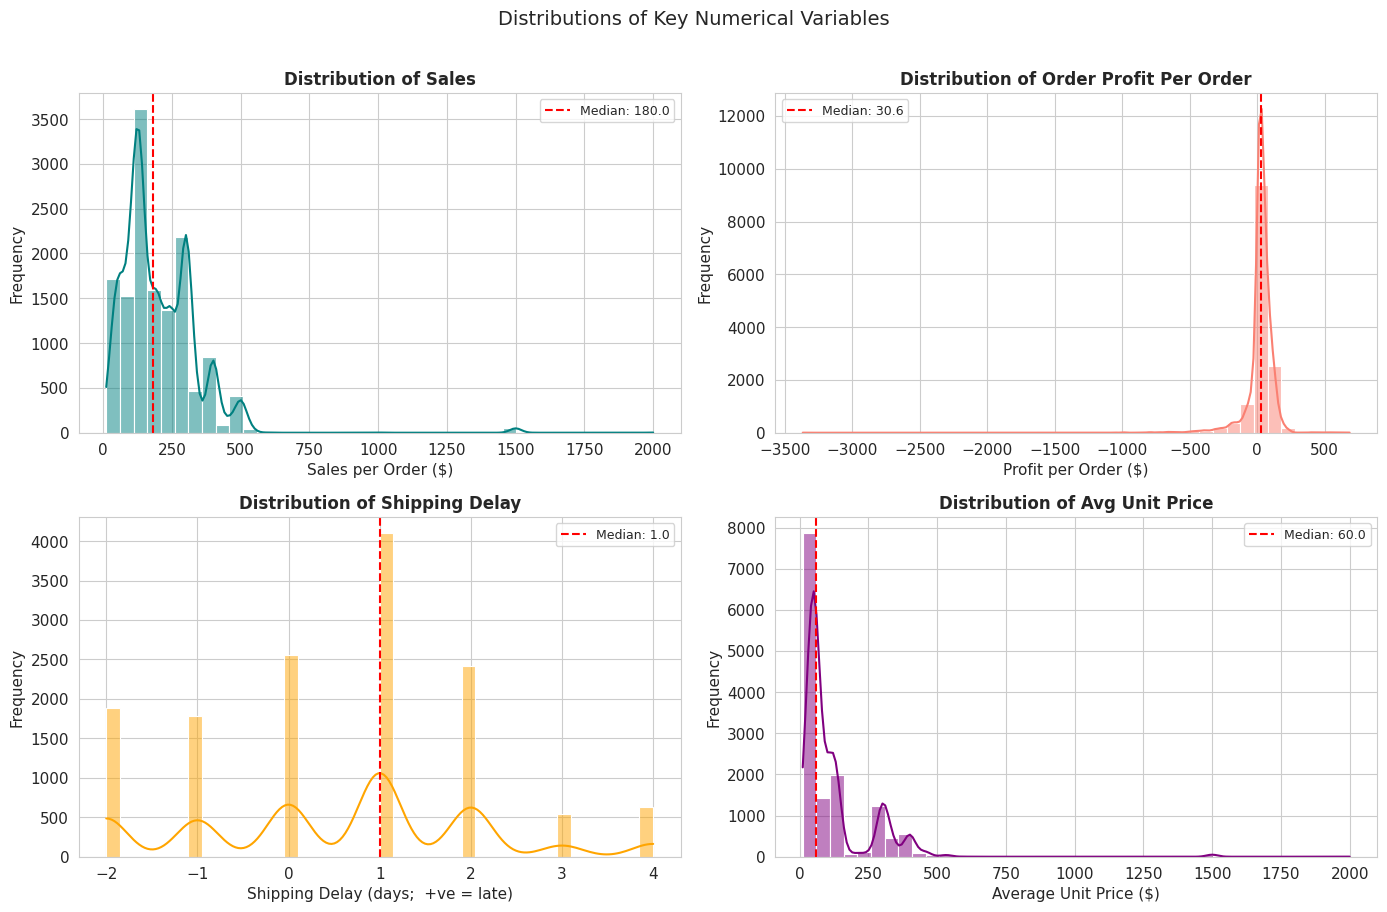


Key statistics:
  Sales per Order ($)                       Mean=  203.70  Median=  179.97  Std=  142.93  Skew=  3.39
  Profit per Order ($)                      Mean=   21.31  Median=   30.57  Std=  113.85  Skew= -6.61
  Shipping Delay (days;  +ve = late)        Mean=    0.54  Median=    1.00  Std=    1.56  Skew=  0.08
  Average Unit Price ($)                    Mean=  122.88  Median=   59.99  Std=  141.38  Skew=  4.51


In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Distributions of Key Numerical Variables', fontsize=14, y=1.01)

plot_cfg = [
    ('Sales',                   'teal',   'Sales per Order ($)'),
    ('Order Profit Per Order',  'salmon', 'Profit per Order ($)'),
    ('Shipping Delay',          'orange', 'Shipping Delay (days;  +ve = late)'),
    ('Avg Unit Price',          'purple', 'Average Unit Price ($)'),
]

for ax, (col, color, xlabel) in zip(axes.flat, plot_cfg):
    sns.histplot(df[col], bins=40, color=color, kde=True, ax=ax)
    med = df[col].median()
    ax.axvline(med, color='red', linestyle='--', linewidth=1.5,
               label=f'Median: {med:.1f}')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of {col}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("\nKey statistics:")
for col, _, lbl in plot_cfg:
    print(f"  {lbl:<40}  "
          f"Mean={df[col].mean():>8.2f}  "
          f"Median={df[col].median():>8.2f}  "
          f"Std={df[col].std():>8.2f}  "
          f"Skew={df[col].skew():>6.2f}")

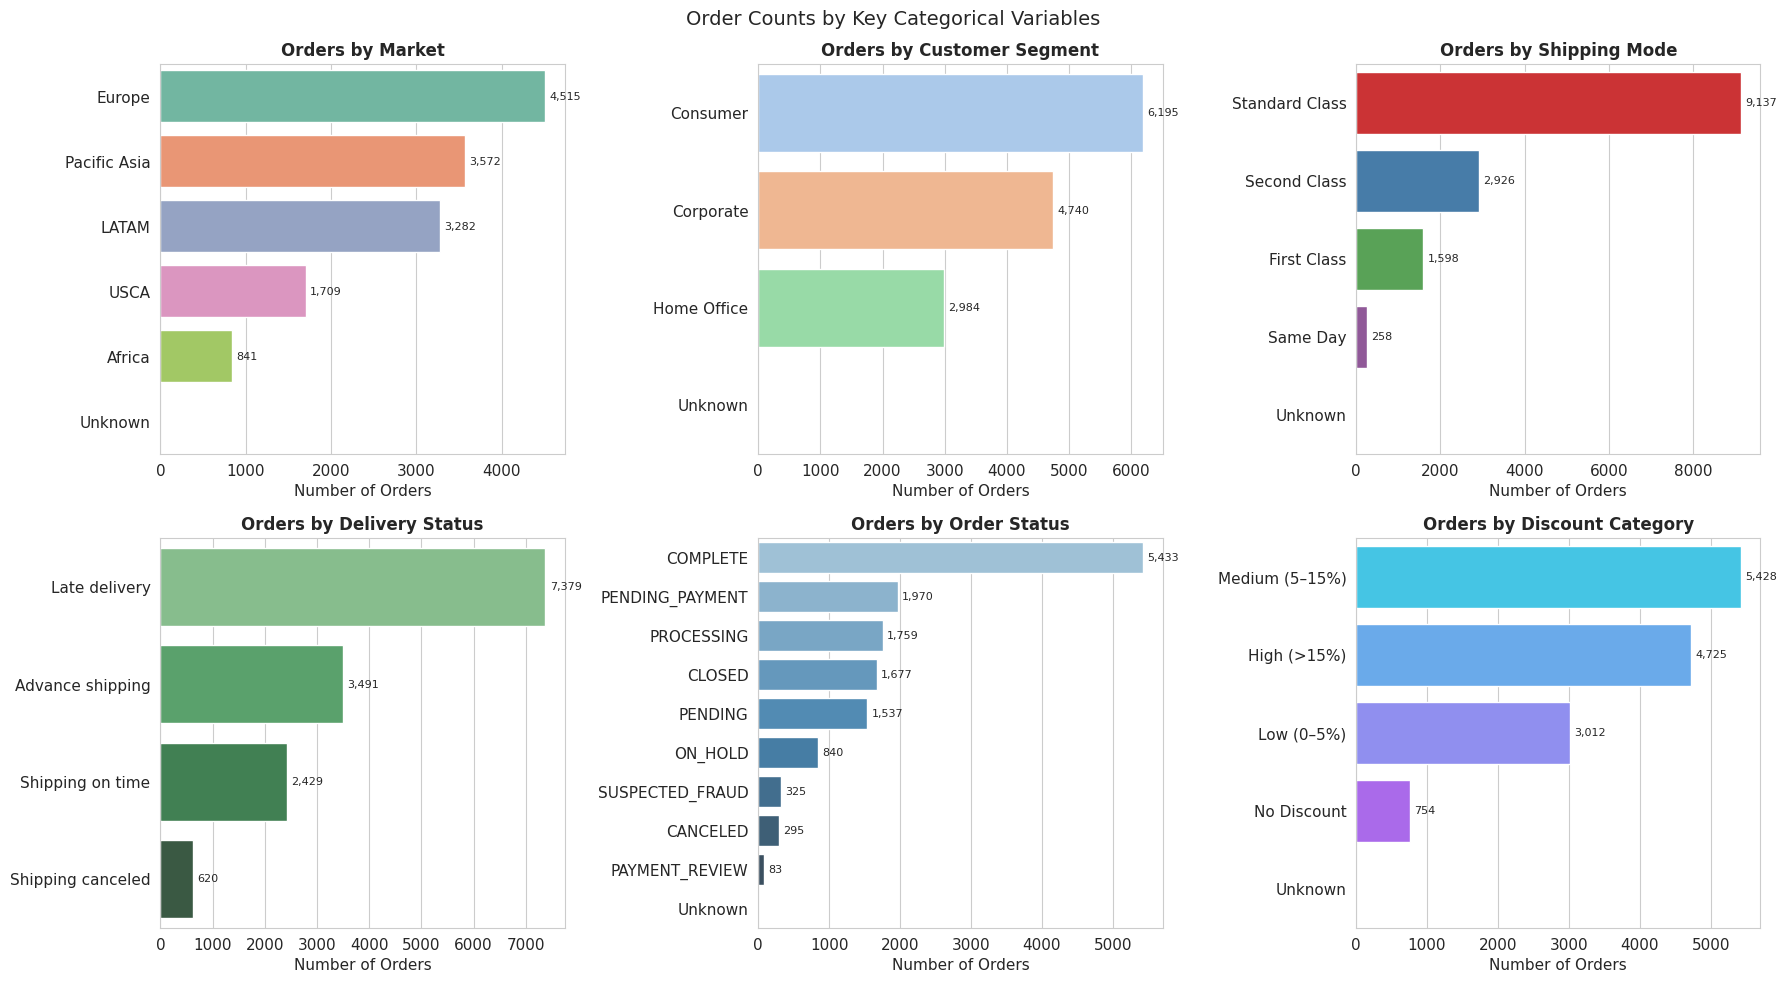

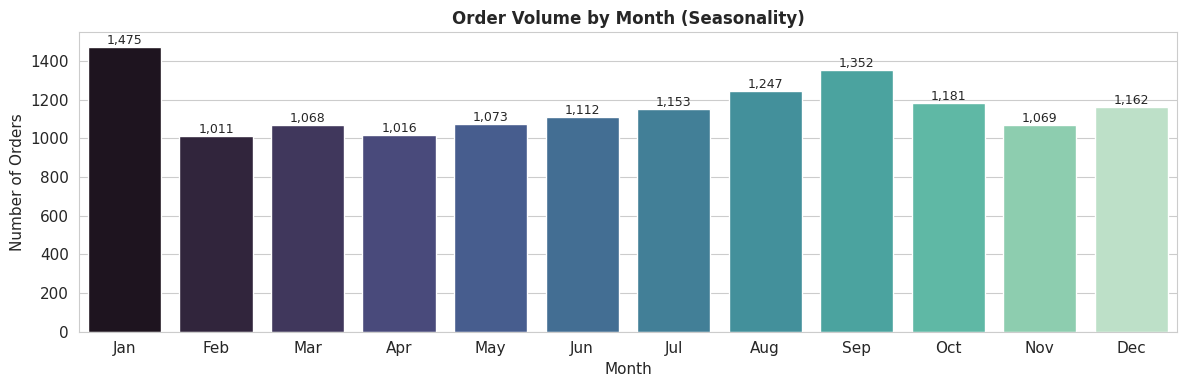

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Order Counts by Key Categorical Variables', fontsize=14)

cat_cfg = [
    ('Market',             'Set2'),
    ('Customer Segment',   'pastel'),
    ('Shipping Mode',      'Set1'),
    ('Delivery Status',    'Greens_d'),
    ('Order Status',       'Blues_d'),
    ('Discount Category',  'cool'),
]

for ax, (col, palette) in zip(axes.flat, cat_cfg):
    order = df[col].value_counts().index
    sns.countplot(y=col, data=df, order=order, palette=palette, ax=ax)
    ax.set_xlabel('Number of Orders')
    ax.set_ylabel('')
    ax.set_title(f'Orders by {col}')
    for p in ax.patches:
        ax.annotate(
            f'{int(p.get_width()):,}',
            (p.get_width(), p.get_y() + p.get_height() / 2),
            ha='left', va='center', fontsize=8,
            xytext=(3, 0), textcoords='offset points'
        )

plt.tight_layout()
plt.show()

# ── Monthly seasonality ───────────────────────────────────────────────────────
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
month_counts = df['Order Month'].value_counts().sort_index()

plt.figure(figsize=(12, 4))
ax = sns.barplot(
    x=[month_labels[int(m) - 1] for m in month_counts.index],
    y=month_counts.values,
    palette='mako'
)
plt.title('Order Volume by Month (Seasonality)')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom', fontsize=9
    )
plt.tight_layout()
plt.show()

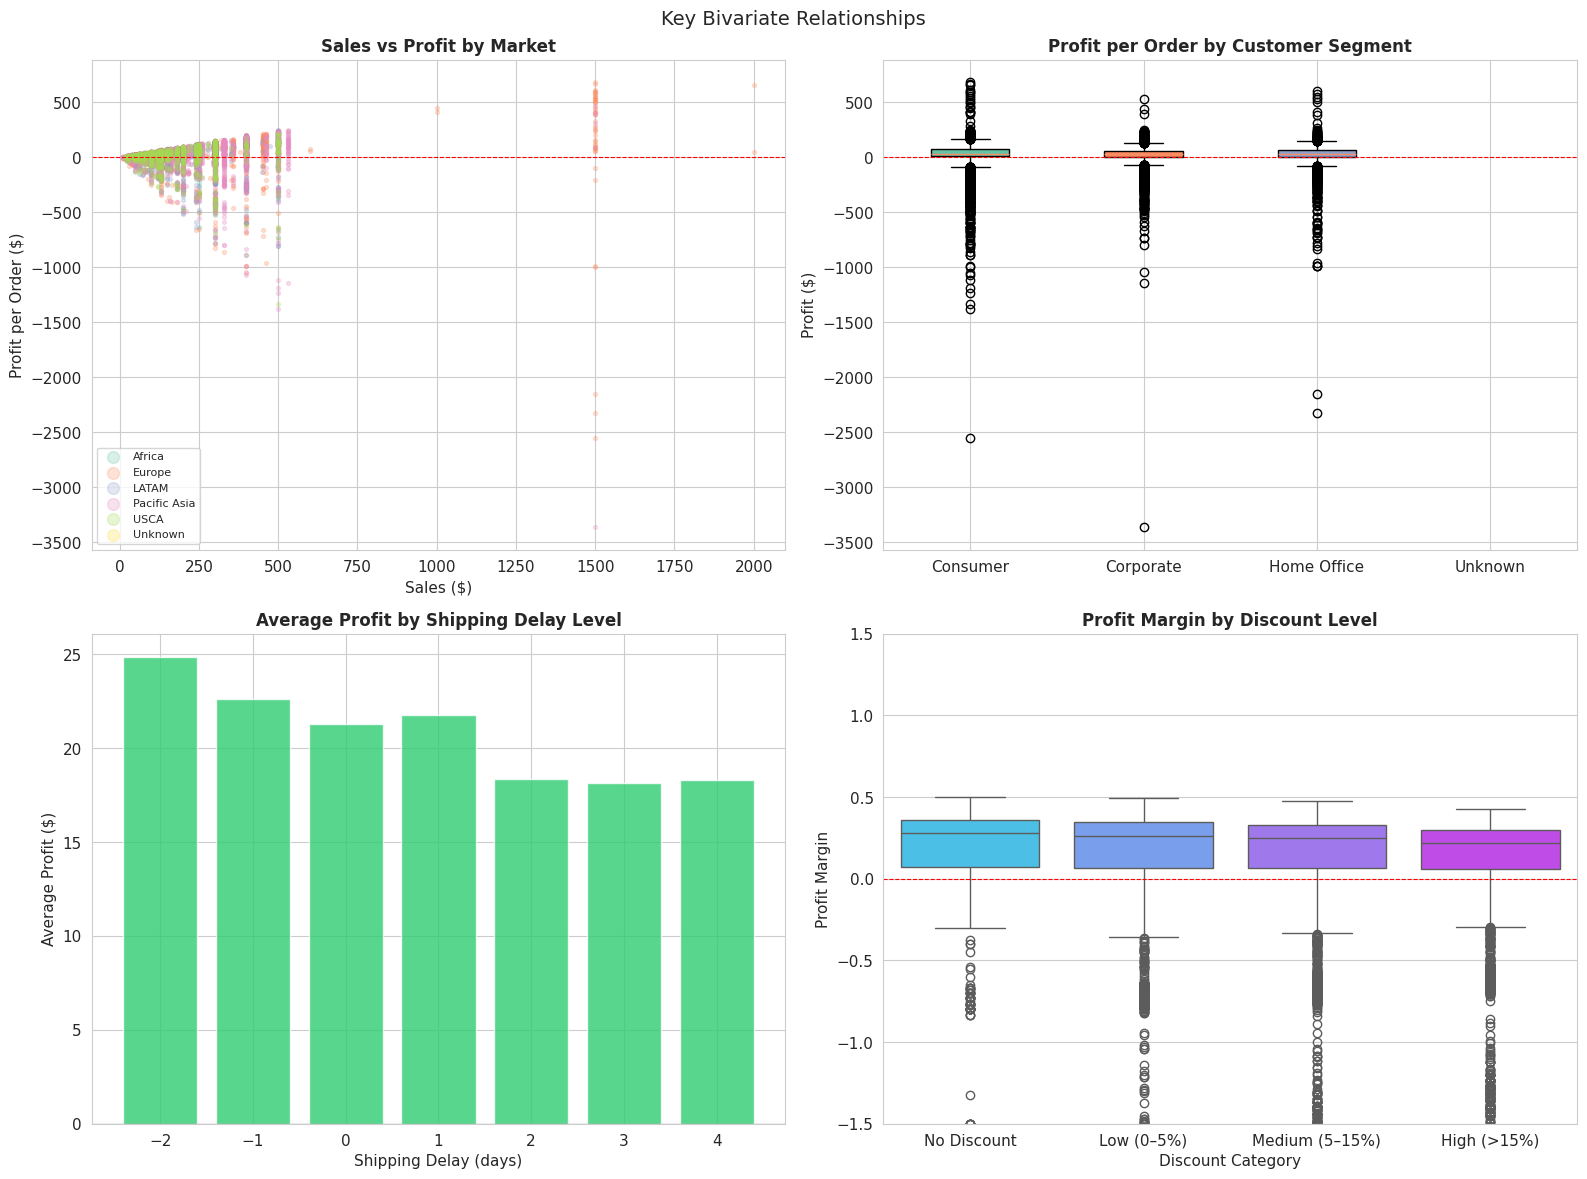

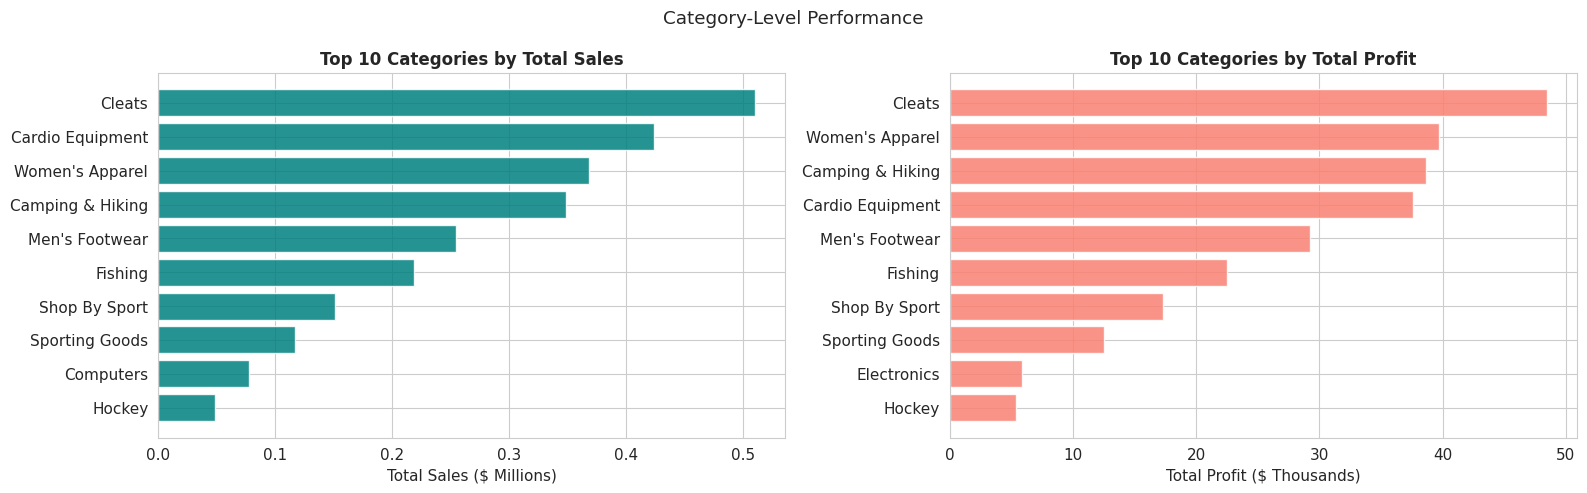

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Key Bivariate Relationships', fontsize=14)

# 1. Sales vs Profit by Market
ax = axes[0, 0]
for mkt in df['Market'].cat.categories:
    sub = df[df['Market'] == mkt]
    ax.scatter(sub['Sales'], sub['Order Profit Per Order'],
               alpha=0.25, s=8, label=mkt)
ax.set_xlabel('Sales ($)')
ax.set_ylabel('Profit per Order ($)')
ax.set_title('Sales vs Profit by Market')
ax.legend(fontsize=8, markerscale=3)
ax.axhline(0, color='red', linestyle='--', linewidth=0.8, label='Break-even')

# 2. Profit by Customer Segment
ax = axes[0, 1]
segments = df['Customer Segment'].cat.categories.tolist()
colors = sns.color_palette('Set2', len(segments))
bp = ax.boxplot(
    [df[df['Customer Segment'] == s]['Order Profit Per Order'].dropna() for s in segments],
    labels=segments, patch_artist=True, notch=False
)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.set_title('Profit per Order by Customer Segment')
ax.set_ylabel('Profit ($)')
ax.axhline(0, color='red', linestyle='--', linewidth=0.8)

# 3. Average Profit by Shipping Delay value
ax = axes[1, 0]
delay_profit = (df.groupby('Shipping Delay')['Order Profit Per Order']
                  .mean()
                  .reset_index()
                  .sort_values('Shipping Delay'))
colors_bar = ['#e74c3c' if v < 0 else '#2ecc71'
              for v in delay_profit['Order Profit Per Order']]
ax.bar(delay_profit['Shipping Delay'], delay_profit['Order Profit Per Order'],
       color=colors_bar, alpha=0.8)
ax.set_xlabel('Shipping Delay (days)')
ax.set_ylabel('Average Profit ($)')
ax.set_title('Average Profit by Shipping Delay Level')
ax.axhline(0, color='black', linewidth=0.8)

# 4. Profit Margin by Discount Category
ax = axes[1, 1]
disc_order = ['No Discount', 'Low (0–5%)', 'Medium (5–15%)', 'High (>15%)']
valid_order = [d for d in disc_order if d in df['Discount Category'].cat.categories]
sns.boxplot(
    x='Discount Category', y='Profit Margin',
    data=df.dropna(subset=['Discount Category']),
    order=valid_order, palette='cool', ax=ax
)
ax.set_title('Profit Margin by Discount Level')
ax.set_ylabel('Profit Margin')
ax.set_ylim(-1.5, 1.5)
ax.axhline(0, color='red', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

# ── Top categories ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Category-Level Performance')

top_s = df.groupby('Category Name')['Sales'].sum().nlargest(10).sort_values()
top_p = df.groupby('Category Name')['Order Profit Per Order'].sum().nlargest(10).sort_values()

axes[0].barh(top_s.index, top_s.values / 1e6, color='teal', alpha=0.85)
axes[0].set_title('Top 10 Categories by Total Sales')
axes[0].set_xlabel('Total Sales ($ Millions)')

axes[1].barh(top_p.index, top_p.values / 1e3, color='salmon', alpha=0.85)
axes[1].set_title('Top 10 Categories by Total Profit')
axes[1].set_xlabel('Total Profit ($ Thousands)')

plt.tight_layout()
plt.show()

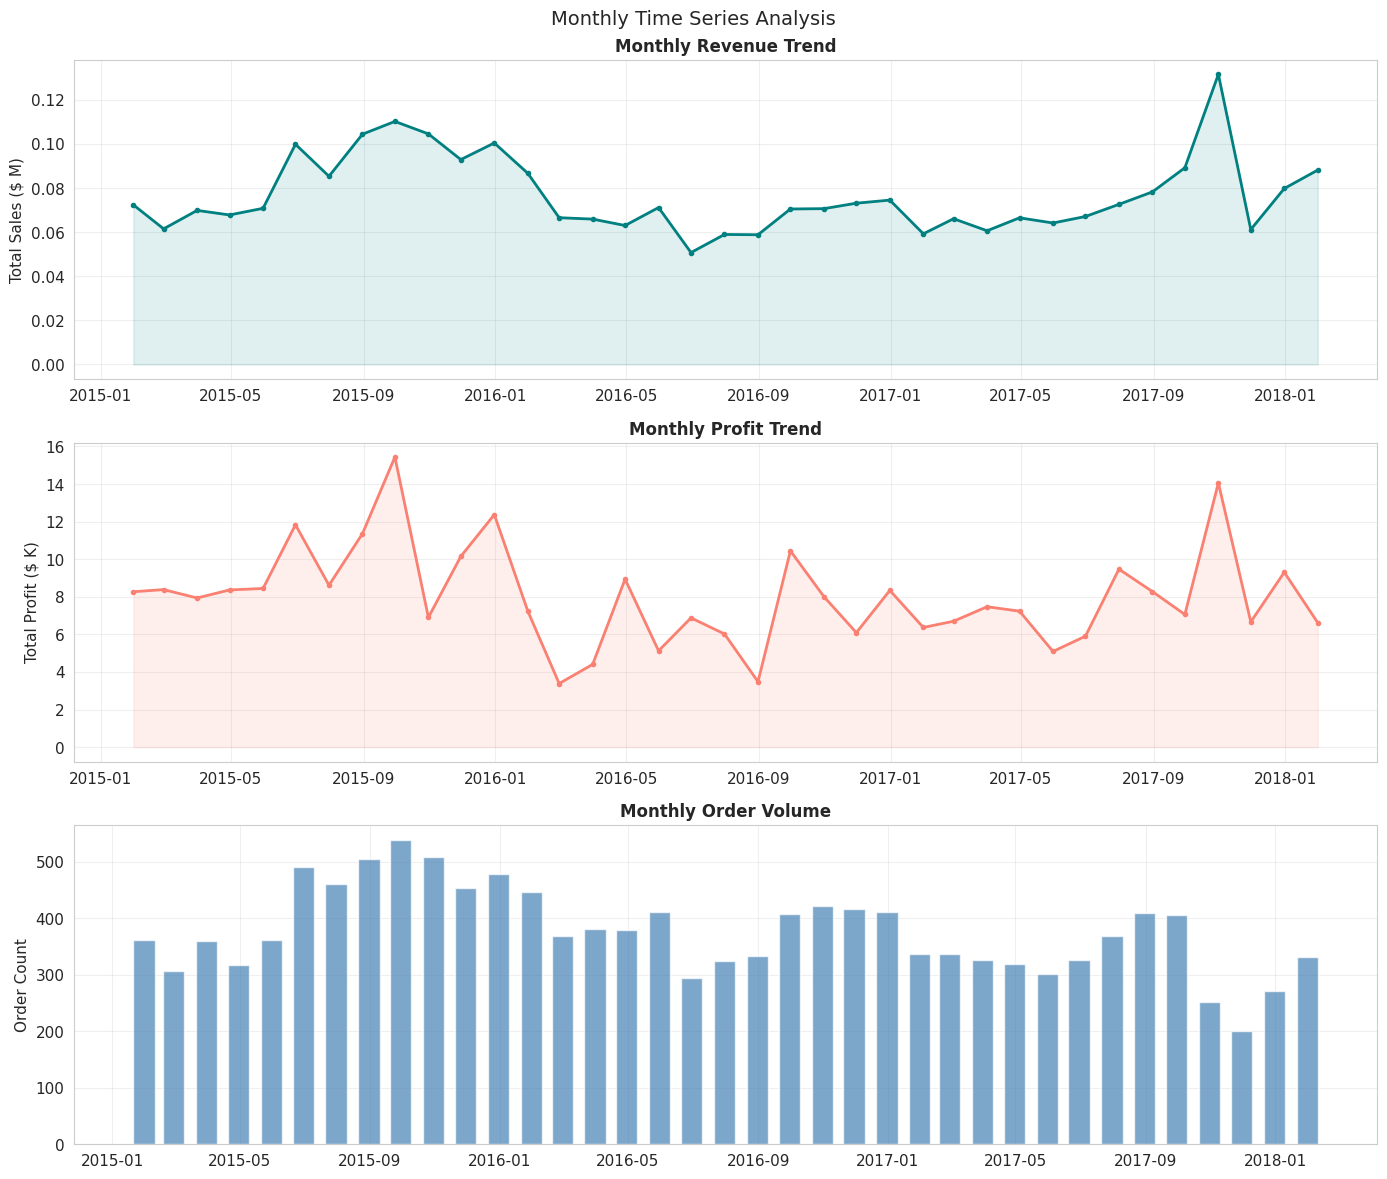

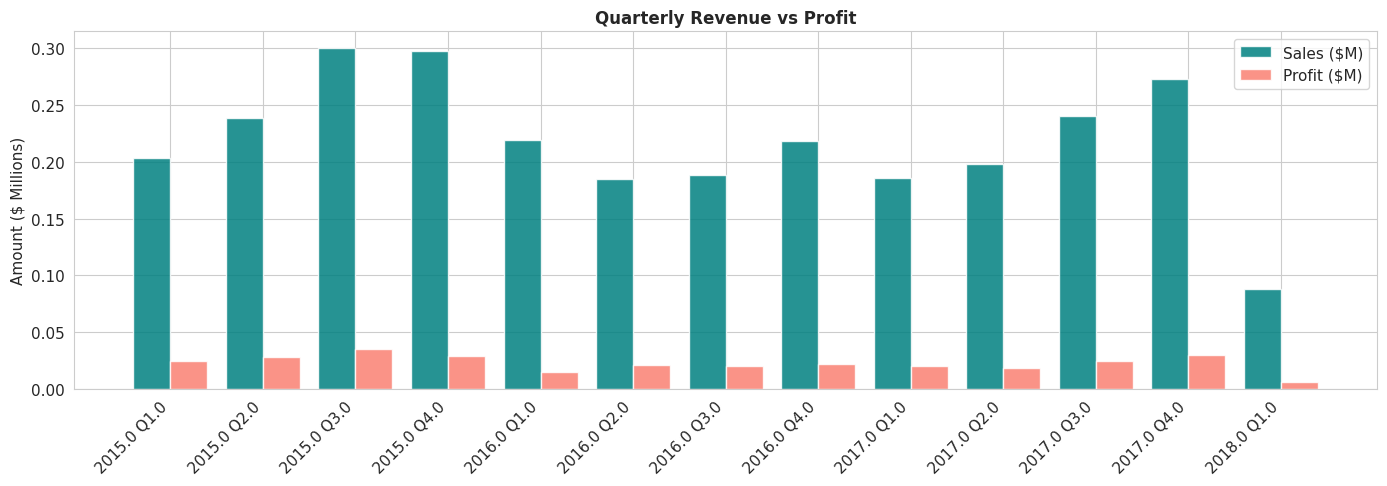

In [24]:
# Monthly aggregation
monthly = (
    df.groupby(pd.Grouper(key='order date (DateOrders)', freq='ME'))
    .agg(
        Total_Sales     = ('Sales',                   'sum'),
        Total_Profit    = ('Order Profit Per Order',  'sum'),
        Order_Count     = ('Order Id',                'count'),
        Avg_Delay       = ('Shipping Delay',          'mean'),
    )
    .reset_index()
    .rename(columns={'order date (DateOrders)': 'Month'})
)

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Monthly Time Series Analysis', fontsize=14)

# Sales
axes[0].plot(monthly['Month'], monthly['Total_Sales'] / 1e6,
             color='teal', linewidth=2, marker='o', markersize=3)
axes[0].fill_between(monthly['Month'], monthly['Total_Sales'] / 1e6,
                     alpha=0.12, color='teal')
axes[0].set_ylabel('Total Sales ($ M)')
axes[0].set_title('Monthly Revenue Trend')

# Profit
axes[1].plot(monthly['Month'], monthly['Total_Profit'] / 1e3,
             color='salmon', linewidth=2, marker='o', markersize=3)
axes[1].fill_between(monthly['Month'], monthly['Total_Profit'] / 1e3,
                     alpha=0.12, color='salmon')
axes[1].set_ylabel('Total Profit ($ K)')
axes[1].set_title('Monthly Profit Trend')

# Order count
axes[2].bar(monthly['Month'], monthly['Order_Count'],
            color='steelblue', alpha=0.7, width=20)
axes[2].set_ylabel('Order Count')
axes[2].set_title('Monthly Order Volume')

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

# ── Quarterly view ────────────────────────────────────────────────────────────
quarterly = (
    df.groupby(['Order Year', 'Order Quarter'])
    .agg(Sales=('Sales','sum'), Profit=('Order Profit Per Order','sum'))
    .reset_index()
    .sort_values(['Order Year', 'Order Quarter'])
)
quarterly['Label'] = (quarterly['Order Year'].astype(str)
                      + ' Q' + quarterly['Order Quarter'].astype(str))

x = range(len(quarterly))
plt.figure(figsize=(14, 5))
plt.bar([i - 0.2 for i in x], quarterly['Sales']  / 1e6, width=0.4,
        label='Sales ($M)',  color='teal',   alpha=0.85)
plt.bar([i + 0.2 for i in x], quarterly['Profit'] / 1e6, width=0.4,
        label='Profit ($M)', color='salmon', alpha=0.85)
plt.xticks(x, quarterly['Label'], rotation=45, ha='right')
plt.ylabel('Amount ($ Millions)')
plt.title('Quarterly Revenue vs Profit')
plt.legend()
plt.tight_layout()
plt.show()

📊 Market Performance Summary:


,Market,Total_Sales,Total_Profit,Order_Count,Avg_Delay,Late_Rate,Margin_Pct
1,Europe,988379.39,105468.63,4515,0.53,0.56,10.67
3,Pacific Asia,749172.12,71284.00,3572,0.53,0.54,9.52
2,LATAM,656802.65,72236.33,3282,0.60,0.56,11.00
4,USCA,297395.26,31562.58,1709,0.57,0.55,10.61
0,Africa,143575.73,16091.94,841,0.38,0.52,11.21


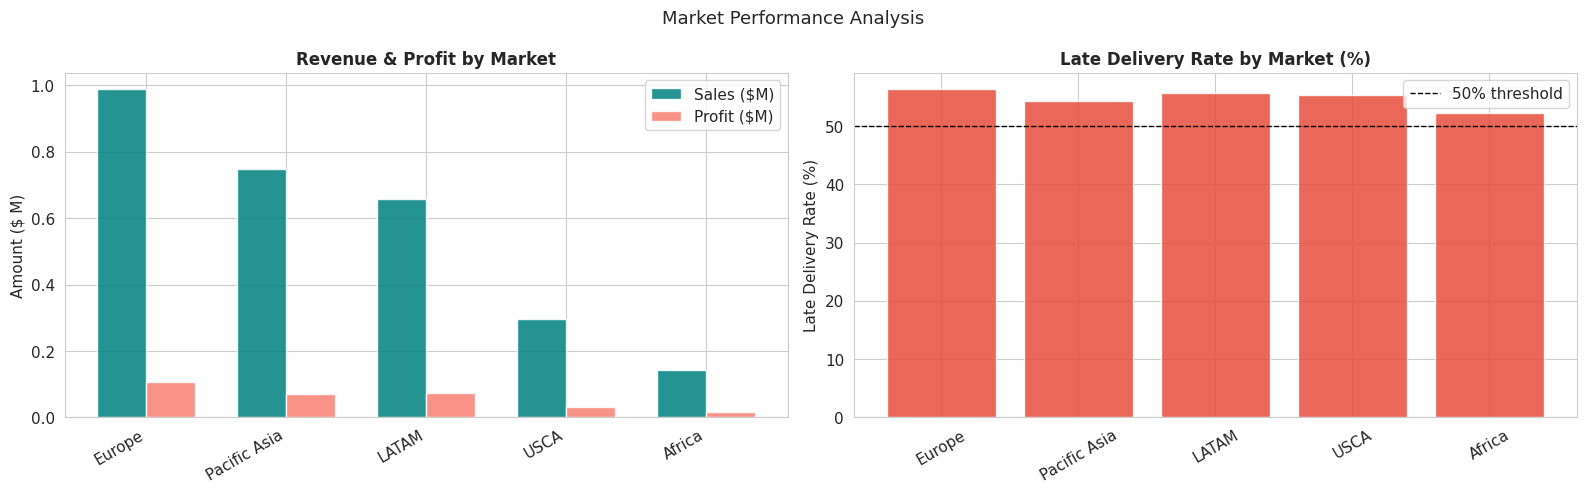

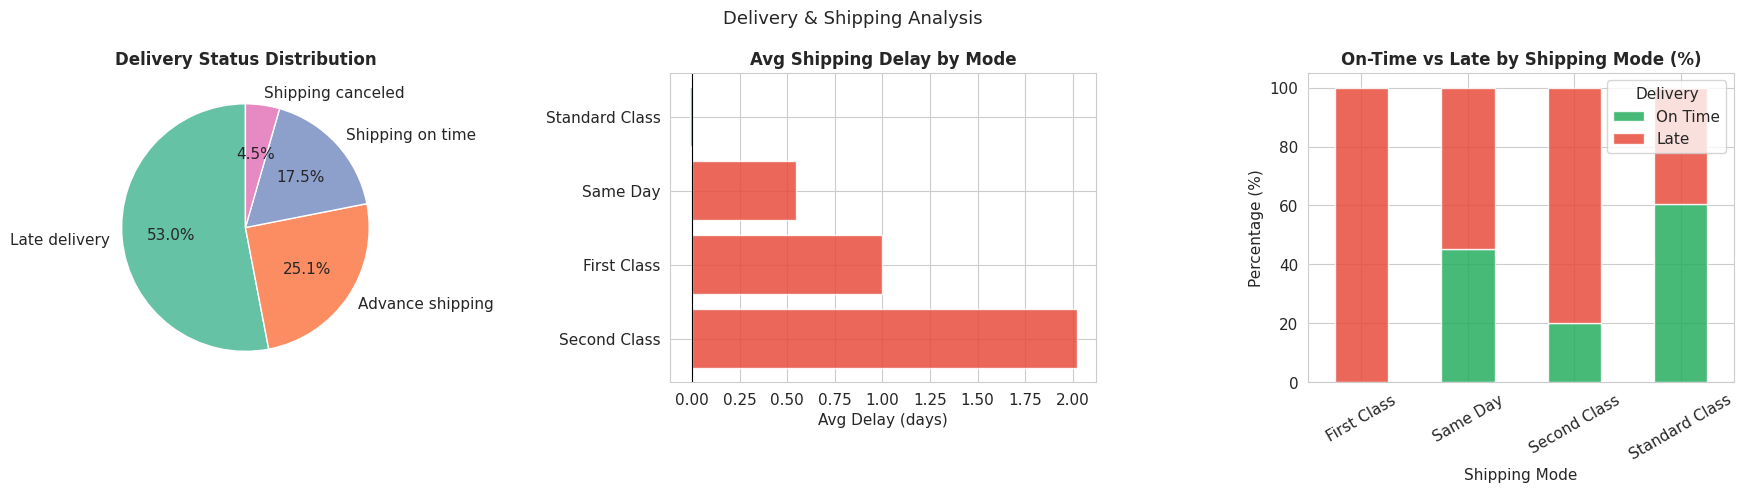

In [25]:
# ── Market summary table ──────────────────────────────────────────────────────
market_summary = (
    df.groupby('Market', observed=True)
    .agg(
        Total_Sales     = ('Sales',                  'sum'),
        Total_Profit    = ('Order Profit Per Order', 'sum'),
        Order_Count     = ('Order Id',               'count'),
        Avg_Delay       = ('Shipping Delay',         'mean'),
        Late_Rate       = ('Is Late',                'mean'),
    )
    .reset_index()
    .sort_values('Total_Sales', ascending=False)
)
market_summary['Margin_Pct'] = (
    market_summary['Total_Profit'] / market_summary['Total_Sales'] * 100
).round(2)

print("📊 Market Performance Summary:")
display(market_summary.round(2))

# ── Market charts ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Revenue & Profit grouped bar
x = range(len(market_summary))
w = 0.35
axes[0].bar([i - w/2 for i in x], market_summary['Total_Sales']  / 1e6,
            w, label='Sales ($M)',  color='teal',   alpha=0.85)
axes[0].bar([i + w/2 for i in x], market_summary['Total_Profit'] / 1e6,
            w, label='Profit ($M)', color='salmon', alpha=0.85)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(market_summary['Market'], rotation=30, ha='right')
axes[0].set_title('Revenue & Profit by Market')
axes[0].set_ylabel('Amount ($ M)')
axes[0].legend()

# Late delivery rate
rate_colors = ['#e74c3c' if r > 0.5 else '#f39c12' if r > 0.3 else '#27ae60'
               for r in market_summary['Late_Rate']]
axes[1].bar(market_summary['Market'], market_summary['Late_Rate'] * 100,
            color=rate_colors, alpha=0.85)
axes[1].axhline(50, color='black', linestyle='--', linewidth=1,
                label='50% threshold')
axes[1].set_title('Late Delivery Rate by Market (%)')
axes[1].set_ylabel('Late Delivery Rate (%)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

plt.suptitle('Market Performance Analysis', fontsize=13)
plt.tight_layout()
plt.show()

# ── Delivery analysis ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Delivery & Shipping Analysis', fontsize=13)

# Pie: delivery status
d_counts = df['Delivery Status'].value_counts()
axes[0].pie(d_counts.values, labels=d_counts.index,
            autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(d_counts)),
            startangle=90)
axes[0].set_title('Delivery Status Distribution')

# Avg delay by shipping mode
mode_delay = (df.groupby('Shipping Mode', observed=True)['Shipping Delay']
                .mean()
                .sort_values(ascending=False))
bar_colors = ['#e74c3c' if v > 0 else '#27ae60' for v in mode_delay.values]
axes[1].barh(mode_delay.index, mode_delay.values, color=bar_colors, alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Avg Shipping Delay by Mode')
axes[1].set_xlabel('Avg Delay (days)')

# Stacked bar: on-time vs late by mode
late_mode = (df.groupby(['Shipping Mode', 'Is Late'], observed=True)
               .size()
               .unstack(fill_value=0))
late_mode_pct = late_mode.div(late_mode.sum(axis=1), axis=0) * 100
late_mode_pct.plot(kind='bar', stacked=True, ax=axes[2],
                   color=['#27ae60', '#e74c3c'], alpha=0.85)
axes[2].set_title('On-Time vs Late by Shipping Mode (%)')
axes[2].set_xlabel('Shipping Mode')
axes[2].set_ylabel('Percentage (%)')
axes[2].legend(['On Time', 'Late'], title='Delivery', loc='upper right')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

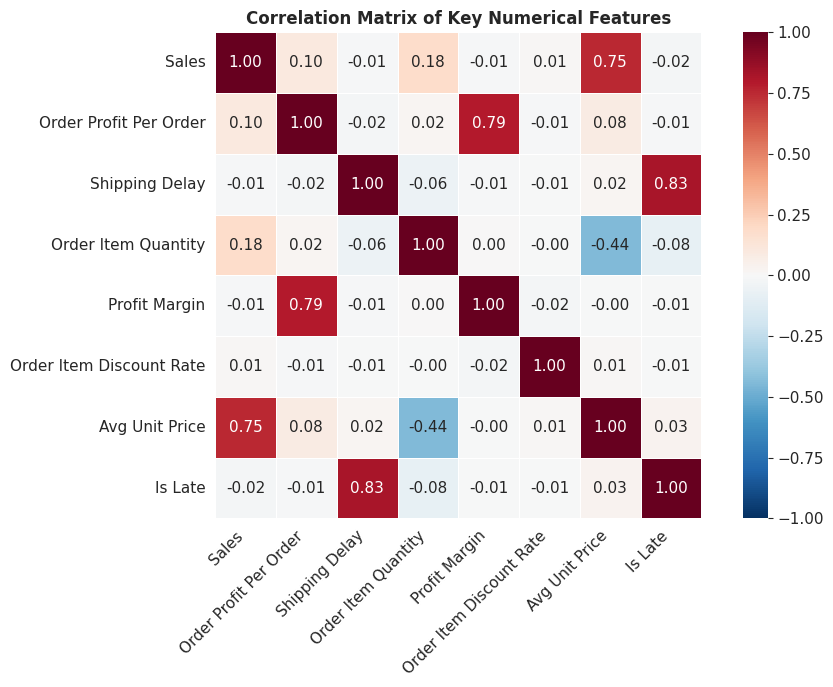


📊 Top correlations with Sales:
Avg Unit Price              0.754288
Order Item Quantity         0.181205
Order Profit Per Order      0.100544
Order Item Discount Rate    0.008697
Profit Margin              -0.011085
Shipping Delay             -0.014790
Is Late                    -0.018398

📊 Top correlations with Profit:
Profit Margin               0.794635
Sales                       0.100544
Avg Unit Price              0.078166
Order Item Quantity         0.018561
Order Item Discount Rate   -0.008315
Is Late                    -0.011265
Shipping Delay             -0.016442


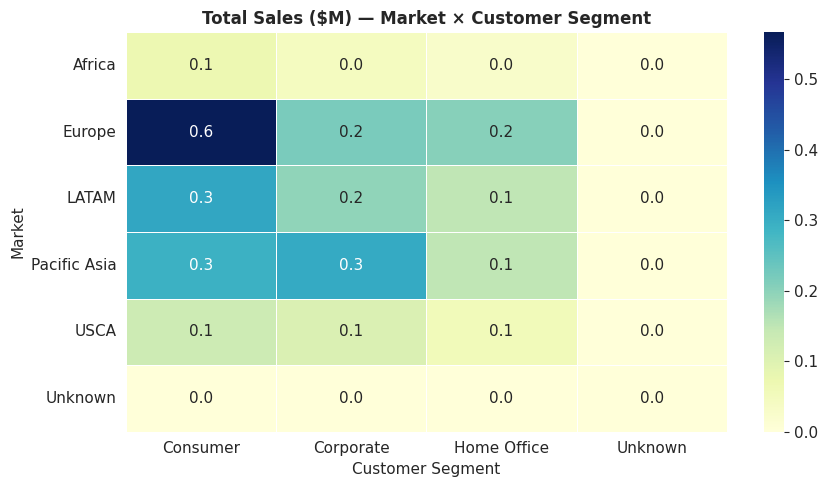

In [26]:
corr_cols = [c for c in [
    'Sales', 'Order Profit Per Order', 'Shipping Delay',
    'Order Item Quantity', 'Profit Margin',
    'Order Item Discount Rate', 'Avg Unit Price', 'Is Late'
] if c in df.columns]

corr = df[corr_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True
)
plt.title('Correlation Matrix of Key Numerical Features')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n📊 Top correlations with Sales:")
print(corr['Sales'].sort_values(ascending=False).drop('Sales').to_string())

print("\n📊 Top correlations with Profit:")
print(corr['Order Profit Per Order'].sort_values(ascending=False)
      .drop('Order Profit Per Order').to_string())

# ── Heatmap: Sales by Market × Customer Segment ───────────────────────────────
pivot_ms = df.pivot_table(
    values='Sales', index='Market',
    columns='Customer Segment', aggfunc='sum'
) / 1e6

plt.figure(figsize=(9, 5))
sns.heatmap(pivot_ms, annot=True, fmt='.1f', cmap='YlGnBu', linewidths=0.5)
plt.title('Total Sales ($M) — Market × Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Market')
plt.tight_layout()
plt.show()

In [27]:
# Helper for consistent output
def print_result(name, h0, stat, p, extra=''):
    decision = '✅ REJECT H\u2080' if p < 0.05 else '❌ FAIL TO REJECT H\u2080'
    print(f"\n{'─'*65}")
    print(f"Test  : {name}")
    print(f"H\u2080    : {h0}")
    print(f"Stat  : {stat:.4f}  |  p-value: {p:.6f}")
    if extra:
        print(f"Info  : {extra}")
    print(f"Result: {decision}  (α = 0.05)")

print("=" * 65)
print("HYPOTHESIS TESTING RESULTS")
print("=" * 65)

# ── H1: Markets differ in profit (Kruskal-Wallis) ────────────────────────────
groups_mkt = [
    df[df['Market'] == m]['Order Profit Per Order'].dropna().values
    for m in df['Market'].cat.categories
]
kw_h, kw_p = kruskal(*groups_mkt)
medians_mkt = (df.groupby('Market', observed=True)['Order Profit Per Order']
                 .median()
                 .sort_values(ascending=False))
print_result(
    'Kruskal-Wallis H (markets vs profit)',
    'All markets share the same median profit per order',
    kw_h, kw_p,
    f'Market medians → {medians_mkt.to_dict()}'
)

# ── H2: Shipping mode and late delivery (Chi-Square) ─────────────────────────
contingency = pd.crosstab(df['Shipping Mode'], df['Is Late'])
chi2_stat, chi2_p, chi2_dof, _ = chi2_contingency(contingency)
late_by_mode = (df.groupby('Shipping Mode', observed=True)['Is Late']
                  .mean()
                  .sort_values(ascending=False) * 100)
print_result(
    'Chi-Square test (shipping mode vs late delivery)',
    'Shipping mode and late delivery risk are independent',
    chi2_stat, chi2_p,
    f'DoF={chi2_dof}  |  Late rates: {late_by_mode.round(1).to_dict()}'
)

# ── H3: Consumer vs Corporate profit (Mann-Whitney U) ─────────────────────────
cons_profit = df[df['Customer Segment']=='Consumer']['Order Profit Per Order'].dropna()
corp_profit = df[df['Customer Segment']=='Corporate']['Order Profit Per Order'].dropna()
mw_stat, mw_p = mannwhitneyu(cons_profit, corp_profit, alternative='two-sided')
print_result(
    'Mann-Whitney U (Consumer vs Corporate profit)',
    'Consumer and Corporate segments share the same profit distribution',
    mw_stat, mw_p,
    f'Consumer median=${cons_profit.median():.2f}  |  Corporate median=${corp_profit.median():.2f}'
)

# ── H4: Discount rate vs profit margin (Pearson) ─────────────────────────────
valid = df[['Order Item Discount Rate','Profit Margin']].dropna()
r_val, r_p = pearsonr(valid['Order Item Discount Rate'], valid['Profit Margin'])
print_result(
    'Pearson r (discount rate vs profit margin)',
    'No linear relationship between discount rate and profit margin  (r = 0)',
    abs(r_val), r_p,
    f'Pearson r = {r_val:.4f}  ({"negative" if r_val < 0 else "positive"} relationship)'
)

# ── H5: Late vs on-time profit (Mann-Whitney U, one-sided) ───────────────────
ontime = df[df['Is Late']==0]['Order Profit Per Order'].dropna()
late   = df[df['Is Late']==1]['Order Profit Per Order'].dropna()
mw2_stat, mw2_p = mannwhitneyu(ontime, late, alternative='greater')
print_result(
    'Mann-Whitney U — one-sided (on-time profit > late profit)',
    'On-time orders do NOT have higher profit than late orders',
    mw2_stat, mw2_p,
    f'On-time median=${ontime.median():.2f}  |  Late median=${late.median():.2f}'
)

print(f"\n{'='*65}")
print("✅ All hypothesis tests completed.")

# Store key results for Insights section
_r_discount = r_val
_cons_med   = cons_profit.median()
_corp_med   = corp_profit.median()
_ontime_med = ontime.median()
_late_med   = late.median()

HYPOTHESIS TESTING RESULTS

─────────────────────────────────────────────────────────────────
Test  : Kruskal-Wallis H (markets vs profit)
H₀    : All markets share the same median profit per order
Stat  : nan  |  p-value: nan
Info  : Market medians → {'Europe': 32.40000153, 'LATAM': 31.195000645, 'Pacific Asia': 29.39999962, 'Africa': 29.11000061, 'USCA': 28.0699997}
Result: ❌ FAIL TO REJECT H₀  (α = 0.05)

─────────────────────────────────────────────────────────────────
Test  : Chi-Square test (shipping mode vs late delivery)
H₀    : Shipping mode and late delivery risk are independent
Stat  : 2931.7084  |  p-value: 0.000000
Info  : DoF=3  |  Late rates: {'First Class': 100.0, 'Second Class': 80.0, 'Same Day': 54.7, 'Standard Class': 39.5}
Result: ✅ REJECT H₀  (α = 0.05)

─────────────────────────────────────────────────────────────────
Test  : Mann-Whitney U (Consumer vs Corporate profit)
H₀    : Consumer and Corporate segments share the same profit distribution
Stat  : 15742346.50

In [29]:
# ════════════════════════════════════════════════════════
# All figures below are COMPUTED from the data — not hardcoded.
# ════════════════════════════════════════════════════════

# Compute key facts
top_mkt       = df.groupby('Market', observed=True)['Sales'].sum().idxmax()
top_mkt_share = df.groupby('Market', observed=True)['Sales'].sum().max() / df['Sales'].sum() * 100
late_rate_all = df['Is Late'].mean() * 100
worst_mode    = (df.groupby('Shipping Mode', observed=True)['Is Late']
                   .mean().idxmax())
worst_mode_rt = (df.groupby('Shipping Mode', observed=True)['Is Late']
                   .mean().max() * 100)
neg_profit_pct = (df['Order Profit Per Order'] < 0).mean() * 100
best_cat       = (df.groupby('Category Name')['Order Profit Per Order']
                    .sum().idxmax())
best_cat_val   = (df.groupby('Category Name')['Order Profit Per Order']
                    .sum().max() / 1e3)

hi_disc_margin = df[df['Discount Category']=='High (>15%)']['Profit Margin'].median()
no_disc_margin = df[df['Discount Category']=='No Discount']['Profit Margin'].median()

peak_month_num = df['Order Month'].value_counts().idxmax()
month_names    = ['Jan','Feb','Mar','Apr','May','Jun',
                  'Jul','Aug','Sep','Oct','Nov','Dec']
peak_month     = month_names[int(peak_month_num) - 1]

print("=" * 70)
print("BUSINESS INSIGHTS & RECOMMENDATIONS")
print("=" * 70)

insights = [
    (
        "Revenue Concentration",
        f"'{top_mkt}' contributes {top_mkt_share:.1f}% of total revenue.",
        "Prioritise logistics investment and targeted marketing in this market. "
        "Simultaneously develop secondary markets to reduce revenue concentration risk."
    ),
    (
        "Delivery Performance",
        f"{late_rate_all:.1f}% of orders arrive late. "
        f"'{worst_mode}' shipping mode has the highest late rate at {worst_mode_rt:.1f}%.",
        "Review SLAs with underperforming carriers. Offer premium expedited shipping "
        "for high-value orders and time-sensitive customers."
    ),
    (
        "Loss-Making Orders",
        f"{neg_profit_pct:.1f}% of orders generate negative profit.",
        "Identify product categories and customer segments driving losses. "
        "Implement minimum order value thresholds or revise return policies."
    ),
    (
        "Best Profit Category",
        f"'{best_cat}' generates the highest total profit (${best_cat_val:.0f}K).",
        "Allocate more shelf space, inventory budget, and promotional activity "
        "to top-profit categories. Analyse what drives margins there and replicate."
    ),
    (
        "Discount Strategy (Stat: H4)",
        f"Pearson r = {_r_discount:.3f} between discount rate and profit margin — "
        f"significant negative correlation. High-discount orders have median margin "
        f"{hi_disc_margin:.3f} vs {no_disc_margin:.3f} for no-discount orders.",
        "Cap blanket discounts. Switch to targeted, behaviour-triggered discounts "
        "(first purchase, cart abandonment, loyalty tier) to protect margin."
    ),
    (
        "Seasonal Demand",
        f"Peak order volume occurs in {peak_month}.",
        "Build inventory buffers and pre-negotiate carrier capacity 6–8 weeks "
        "before peak months. Launch promotional campaigns 4 weeks ahead of peak."
    ),
    (
        "Profit by Shipping Speed (Stat: H5)",
        f"On-time orders yield median profit ${_ontime_med:.2f} vs "
        f"${_late_med:.2f} for late orders — statistically significant.",
        "Improving on-time delivery is directly tied to higher profit. "
        "Invest in shipment-tracking tools and proactive exception management."
    ),
]

for i, (title, finding, rec) in enumerate(insights, 1):
    print(f"\n{'─'*70}")
    print(f"[{i}] {title}")
    print(f"    📌 Finding      : {finding}")
    print(f"    💡 Recommendation: {rec}")

print(f"\n{'='*70}")
print("✅ Analysis complete. Use these insights to drive strategic decisions.")

BUSINESS INSIGHTS & RECOMMENDATIONS

──────────────────────────────────────────────────────────────────────
[1] Revenue Concentration
    📌 Finding      : 'Europe' contributes 34.9% of total revenue.
    💡 Recommendation: Prioritise logistics investment and targeted marketing in this market. Simultaneously develop secondary markets to reduce revenue concentration risk.

──────────────────────────────────────────────────────────────────────
[2] Delivery Performance
    📌 Finding      : 55.3% of orders arrive late. 'First Class' shipping mode has the highest late rate at 100.0%.
    💡 Recommendation: Review SLAs with underperforming carriers. Offer premium expedited shipping for high-value orders and time-sensitive customers.

──────────────────────────────────────────────────────────────────────
[3] Loss-Making Orders
    📌 Finding      : 18.7% of orders generate negative profit.
    💡 Recommendation: Identify product categories and customer segments driving losses. Implement minimum or

In [31]:
print("\n✅ dashboard_data.csv created successfully.")
print("Run: streamlit run app.py")
print("Open: http://localhost:8501")


✅ dashboard_data.csv created successfully.
Run: streamlit run app.py
Open: http://localhost:8501
